# Modelos de nacimientos y defunciones


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("../../U_1_ProbabilidadEstadistica/data/raw/births-and-deaths-projected-to-2100/births-and-deaths-projected-to-2100.csv")
df.head()

,Entity,Code,Year,Deaths,Projected deaths (Projected),Births,Projected births (Projected)
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [30]:
def graficar(datos, columna, pais):
    datos = datos.dropna(subset=[columna])
    anios = datos["Year"].to_numpy()
    valores = datos[columna].to_numpy()

    X = (anios - anios.min()).reshape(-1, 1)
    anios_futuros = np.arange(anios.min(), 2031)
    X_futuro = (anios_futuros - anios.min()).reshape(-1, 1)

    rl = LinearRegression().fit(X, valores)
    rp = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X, valores)
    rf = RandomForestRegressor(random_state=42).fit(X, valores)

    plt.scatter(anios, valores, color="black", label="Datos")
    plt.plot(anios_futuros, rl.predict(X_futuro), label="RL")
    plt.plot(anios_futuros, rp.predict(X_futuro), label="RP")
    plt.plot(anios_futuros, rf.predict(X_futuro), label="RF")
    plt.title(pais + " - " + columna)
    plt.xlabel("Año")
    plt.ylabel("Personas")
    plt.legend()
    plt.grid()
    plt.show()

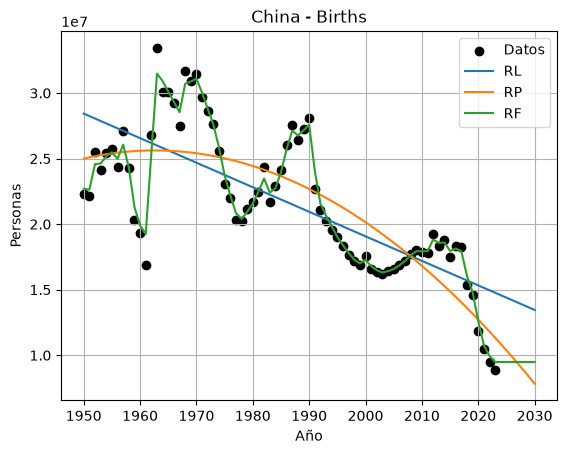

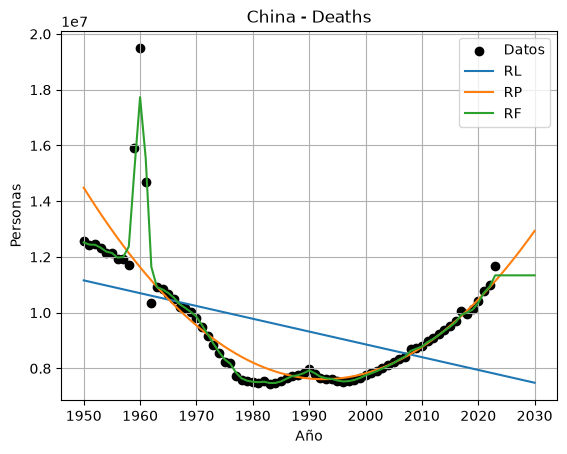

In [31]:
china = df[df["Entity"] == "China"]
china.head()

graficar(china, "Births", "China")
graficar(china, "Deaths", "China")

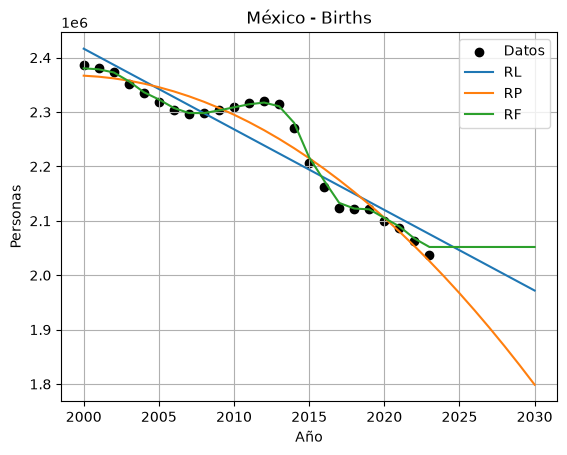

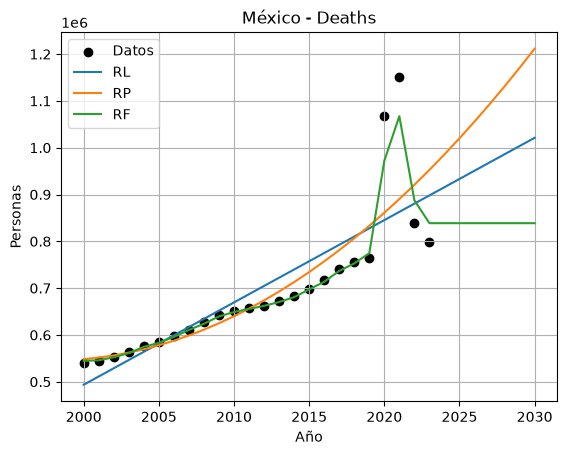

In [32]:
mexico = df[(df["Entity"] == "Mexico") & (df["Year"] >= 2000)]
mexico.head()

graficar(mexico, "Births", "México")
graficar(mexico, "Deaths", "México")